In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])


In [4]:
from torchvision import datasets

base_path = "C:/projects/DL-PNEUMONIA/Radiography"

train_path = base_path + "/train"
val_path   = base_path + "/val"
test_path  = base_path + "/test"

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
val_dataset   = datasets.ImageFolder(root=val_path, transform=transform)
test_dataset  = datasets.ImageFolder(root=test_path, transform=transform)


In [5]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
len(train_dataset)

5216

torch.Size([64, 3, 224, 224])
torch.Size([64])


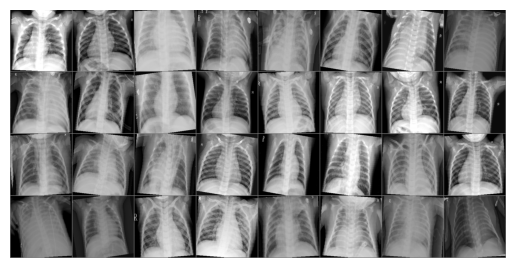

In [9]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

def show_image(img):
    img = img.detach().cpu()
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

grid = torchvision.utils.make_grid(images[:32])
show_image(grid)

In [10]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = PneumoniaCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f} Train Acc: {train_acc:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from PIL import Image
import torch.nn.functional as F

classes = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = predict_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probs = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    label = predicted.item()
    conf = confidence.item()

    print(f"Prediction: {classes[label]}")
    print(f"Confidence: {conf:.4f}")

In [ ]:
predict_image("image6.jpeg")